# NASA MSL/SMAP Spacecraft Telemetry — Exploratory Data Analysis

## Background

The **SMAP** (Soil Moisture Active Passive) and **MSL** (Mars Science Laboratory / Curiosity rover) datasets were released by NASA's Jet Propulsion Laboratory as a benchmark for spacecraft anomaly detection. Each channel represents a telemetry stream: a sensor reading or command state sampled over time during spacecraft operation.

The dataset contains **82 channels** (55 SMAP + 27 MSL), each paired with hand-labeled anomaly windows from NASA engineers. These anomalies were identified in real operations — meaning missed detections had real consequences.

## Why This Dataset Is Challenging

**Contextual vs point anomalies** — the core difficulty:

| Type | Definition | Example |
|------|-----------|--------|
| **Point** | Individual values far outside normal range | Sensor spike from hardware fault |
| **Contextual** | Values normal in isolation, anomalous given surrounding context | Correct sensor reading during wrong operational mode |

43% of sequences are **contextual** — a fixed threshold cannot detect them because the values themselves are within normal range. This is the fundamental motivation for **temporal models** (LSTMs, sequence autoencoders) that learn expected behavior given historical context.

## Train/Test Split Philosophy

- **Train set**: Normal operation only. No anomalies. Used to learn what "nominal" looks like.
- **Test set**: Contains anomaly windows at known indices. Anomaly indices reference test array positions.
- This is **semi-supervised anomaly detection**: we train on normal, detect deviations at test time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import os
from collections import Counter

DATA_ROOT  = '../data/NASA/data/data'
TRAIN_DIR  = f'{DATA_ROOT}/train'
TEST_DIR   = f'{DATA_ROOT}/test'
LABELS_CSV = '../data/NASA/labeled_anomalies.csv'

print('Train files:', len(os.listdir(TRAIN_DIR)))
print('Test files: ', len(os.listdir(TEST_DIR)))

Train files: 82
Test files:  82


In [2]:
# Load labels
df_labels = pd.read_csv(LABELS_CSV)

# anomaly_sequences: valid JSON — use ast.literal_eval
df_labels['anomaly_sequences'] = df_labels['anomaly_sequences'].apply(ast.literal_eval)

# class: bare unquoted words like [contextual, point] — NOT valid Python; use string split
def parse_class(s):
    s = s.strip().lstrip('[').rstrip(']')
    return [x.strip() for x in s.split(',')]

df_labels['class_list'] = df_labels['class'].apply(parse_class)
df_labels['num_sequences'] = df_labels['anomaly_sequences'].apply(len)

# Derive per-row anomaly type summary
def type_summary(types):
    unique = set(types)
    if unique == {'point'}:
        return 'point'
    elif unique == {'contextual'}:
        return 'contextual'
    else:
        return 'mixed'

df_labels['anomaly_type'] = df_labels['class_list'].apply(type_summary)

# Split by spacecraft
msl  = df_labels[df_labels['spacecraft'] == 'MSL'].copy().reset_index(drop=True)
smap = df_labels[df_labels['spacecraft'] == 'SMAP'].copy().reset_index(drop=True)

print(f'Labels shape: {df_labels.shape}')
print(f'MSL channels: {len(msl)},  SMAP channels: {len(smap)}')
print()
print(df_labels.head(4).to_string(index=False))

Labels shape: (82, 8)
MSL channels: 27,  SMAP channels: 55

chan_id spacecraft                          anomaly_sequences                                class  num_values                           class_list  num_sequences anomaly_type
    P-1       SMAP [[2149, 2349], [4536, 4844], [3539, 3779]] [contextual, contextual, contextual]        8505 [contextual, contextual, contextual]              3   contextual
    S-1       SMAP                             [[5300, 5747]]                              [point]        7331                              [point]              1        point
    E-1       SMAP               [[5000, 5030], [5610, 6086]]             [contextual, contextual]        8516             [contextual, contextual]              2   contextual
    E-2       SMAP                             [[5598, 6995]]                              [point]        8532                              [point]              1        point


In [3]:
# Count anomaly types across all sequences
all_types = [t for types in df_labels['class_list'] for t in types]
type_counts = Counter(all_types)

# Compute total test timesteps per spacecraft
def total_test_steps(sub_df):
    return sum(
        len(np.load(f'{TEST_DIR}/{row.chan_id}.npy'))
        for _, row in sub_df.iterrows()
    )

msl_test_steps  = total_test_steps(msl)
smap_test_steps = total_test_steps(smap)

summary = pd.DataFrame({
    'Spacecraft': ['SMAP', 'MSL', 'Total'],
    'Channels':   [len(smap), len(msl), len(df_labels)],
    'Anomaly Sequences': [
        smap['num_sequences'].sum(),
        msl['num_sequences'].sum(),
        df_labels['num_sequences'].sum()
    ],
    'Point Sequences': [
        sum(t == 'point' for types in smap['class_list'] for t in types),
        sum(t == 'point' for types in msl['class_list'] for t in types),
        type_counts['point']
    ],
    'Contextual Sequences': [
        sum(t == 'contextual' for types in smap['class_list'] for t in types),
        sum(t == 'contextual' for types in msl['class_list'] for t in types),
        type_counts['contextual']
    ],
    'Total Test Timesteps': [smap_test_steps, msl_test_steps, smap_test_steps + msl_test_steps]
})

print('=== Dataset Overview ===' )
print(summary.to_string(index=False))

=== Dataset Overview ===
Spacecraft  Channels  Anomaly Sequences  Point Sequences  Contextual Sequences  Total Test Timesteps
      SMAP        55                 69               43                    26                444035
       MSL        27                 36               19                    17                 73729
     Total        82                105               62                    43                517764


## Key Finding: 43% Contextual Anomalies

Of 105 total anomaly sequences, **43 are contextual** (41%). These anomalies have values that fall within the normal range — a fixed threshold will never fire on them.

This means that for ~4 in 10 anomaly windows, any detector that operates purely on value magnitude will fail by construction. This is the **core motivation for temporal models**: an LSTM or sequence autoencoder can learn that a particular value pattern is anomalous *given what preceded it*, even if the value itself is unremarkable.

> **Takeaway**: Threshold-based detectors are a useful baseline, but the dataset is specifically designed to require temporal reasoning for full recall.

---
## Section 2 — MSL Channel Inventory

MSL channels are prefixed by subsystem. The subsystem names are anonymized, but here are possible subsystem mappings:

| Prefix | Subsystem |
|--------|-----------|
| C | Communication |
| D | Data / Avionics |
| F | Flow (propellant/fluid) |
| M | Mobility (wheels/drive) |
| P | Power |
| S | Science instruments |
| T | Temperature |

Each MSL channel has **55 features**:
- **Feature 0**: Primary telemetry signal (the value to detect anomalies in)
- **Features 1–54**: Binary telecommand context (commands sent to the spacecraft)

The telecommand features explain *why* the telemetry behaves as it does — a reading is anomalous if it doesn't match the expected response to the commands being issued. This is precisely why contextual anomalies require more than a threshold on feature 0.

In [4]:
# Build MSL channel inventory table
rows = []
for _, row in msl.iterrows():
    train_arr = np.load(f'{TRAIN_DIR}/{row.chan_id}.npy')
    test_arr  = np.load(f'{TEST_DIR}/{row.chan_id}.npy')
    
    anomaly_steps = sum(e - s + 1 for s, e in row['anomaly_sequences'])
    anomaly_pct   = 100 * anomaly_steps / len(test_arr)
    seq_ranges    = ', '.join(f'[{s},{e}]' for s, e in row['anomaly_sequences'])
    
    rows.append({
        'Channel':        row.chan_id,
        'Train Steps':    len(train_arr),
        'Test Steps':     len(test_arr),
        'Features':       train_arr.shape[1],
        '# Sequences':    row['num_sequences'],
        'Anomaly Steps':  anomaly_steps,
        'Anomaly %':      f'{anomaly_pct:.1f}%',
        'Type':           row['anomaly_type'],
    })

inventory = pd.DataFrame(rows).sort_values('Channel').reset_index(drop=True)
print(inventory.to_string(index=False))

Channel  Train Steps  Test Steps  Features  # Sequences  Anomaly Steps Anomaly %       Type
    C-1         2158        2264        55            2            312     13.8%      mixed
    C-2          764        2051        55            2            137      6.7%      mixed
   D-14         3675        2625        55            2            222      8.5%      point
   D-15         2074        2158        55            1            641     29.7%      point
   D-16         1451        2191        55            1            651     29.7% contextual
    F-4         2244        3422        55            1             71      2.1%      point
    F-5         2598        3922        55            1            151      3.9%      point
    F-7         2511        5054        55            3            423      8.4% contextual
    F-8         3342        2487        55            1            537     21.6% contextual
    M-1         2209        2277        55            1           1141     50.1%

### Channel Inventory Observations

1. **M-1 and M-2 both show ~50% anomaly coverage** with a single long contextual sequence. These likely represent the same rover mobility fault captured on two correlated sensors — a labeling nuance where the same physical event appears on multiple channels.

2. **S-2 has the lowest anomaly density** (<1%) with a single short sequence — a brief point anomaly against thousands of normal timesteps. This is a worst-case precision scenario for detectors.

3. **D-15 and D-16** (deployment arm) have different anomaly patterns (point vs contextual) despite being in the same subsystem — the same mechanical event can manifest differently in different sensor streams.

4. **Train/test lengths vary considerably** across channels (e.g., M-6 has 1565 train steps vs 2049 test steps; F-8 has much longer test windows). There is no fixed ratio.

5. **All channels have 55 features** (the MSL standard) regardless of subsystem — features 1–54 are the same telecommand encoding, making cross-channel transfer learning plausible.

---
## Section 3 — Feature Space

M-1 train shape: (2209, 55)  range: [-0.916, 2.492]
M-1 test  shape: (2277, 55)   range: [-1.076,  2.269]

Feature 0 (telemetry) — Train: mean=0.416, std=0.692
Feature 0 (telemetry) — Test:  mean=0.568,  std=0.806

Features 1-54 (telecommand) — unique values: [0.0, 1.0]


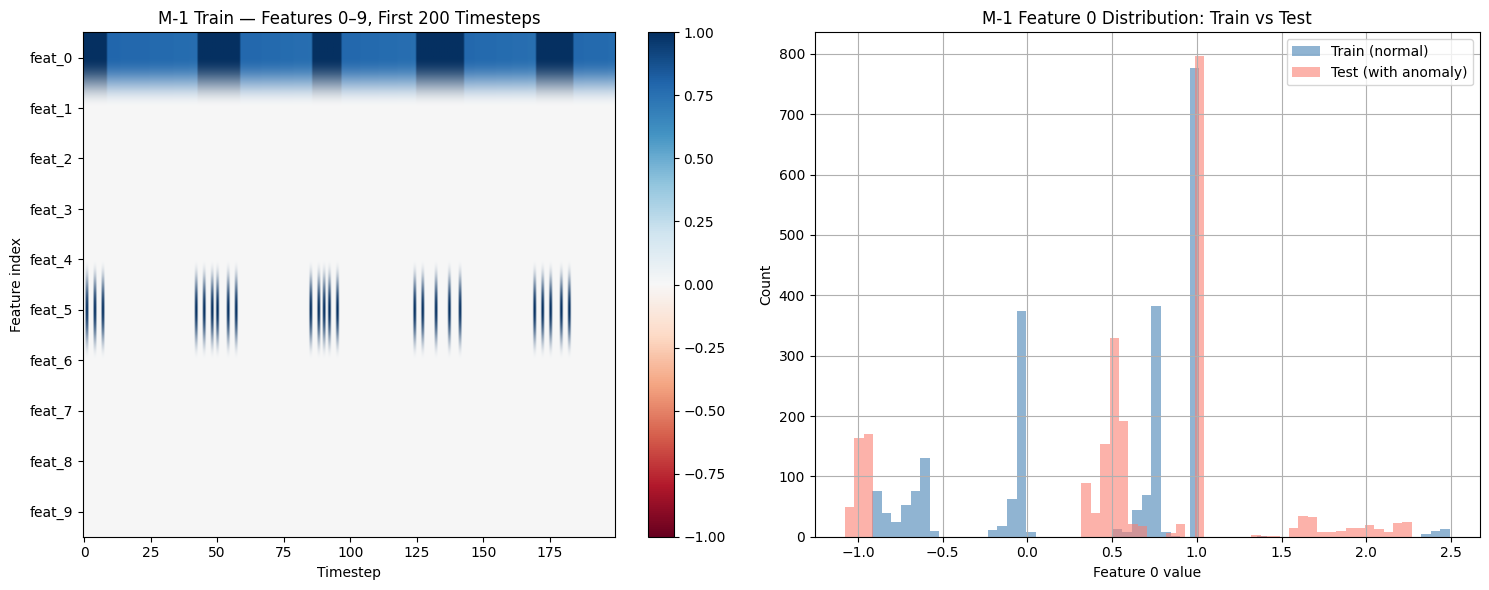

In [5]:
# Load M-1 as example and visualize feature structure
m1_train = np.load(f'{TRAIN_DIR}/M-1.npy')
m1_test  = np.load(f'{TEST_DIR}/M-1.npy')

print(f'M-1 train shape: {m1_train.shape}  range: [{m1_train.min():.3f}, {m1_train.max():.3f}]')
print(f'M-1 test  shape: {m1_test.shape}   range: [{m1_test.min():.3f},  {m1_test.max():.3f}]')
print()
print(f'Feature 0 (telemetry) — Train: mean={m1_train[:,0].mean():.3f}, std={m1_train[:,0].std():.3f}')
print(f'Feature 0 (telemetry) — Test:  mean={m1_test[:,0].mean():.3f},  std={m1_test[:,0].std():.3f}')
print()
print(f'Features 1-54 (telecommand) — unique values: {np.unique(m1_train[:,1:]).tolist()}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: heatmap of first 10 features, first 200 timesteps
ax = axes[0]
im = ax.imshow(m1_train[:200, :10].T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel('Timestep')
ax.set_ylabel('Feature index')
ax.set_title('M-1 Train — Features 0–9, First 200 Timesteps')
ax.set_yticks(range(10))
ax.set_yticklabels([f'feat_{i}' for i in range(10)])
plt.colorbar(im, ax=ax)

# Right: histogram of feature 0 — train vs test
ax = axes[1]
ax.hist(m1_train[:, 0], bins=60, alpha=0.6, label='Train (normal)', color='steelblue')
ax.hist(m1_test[:, 0],  bins=60, alpha=0.6, label='Test (with anomaly)', color='salmon')
ax.set_xlabel('Feature 0 value')
ax.set_ylabel('Count')
ax.set_title('M-1 Feature 0 Distribution: Train vs Test')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

### Feature Space Summary

- **Feature 0** is the continuous telemetry signal — this is what we train detectors to monitor. It is normalized to approximately [-1, 1] using training set statistics.
- **Features 1–54** are binary telecommand context: 0.0 or 1.0 indicating whether specific commands were active at each timestep. The heatmap reveals these switching on/off in structured patterns.

**Normalization caveat**: Values are normalized using *training* statistics. Because test anomalies can represent out-of-distribution hardware behavior, test values can far exceed the training range. M-6 is the extreme case: training feature 0 is exactly flat at -1.0 (constant normal behavior), while the test set contains a spike reaching **258** — the sensor reading during the anomaly is 259 standard deviations outside the training distribution.

This means: for M-6, even a simple threshold on feature 0 will work perfectly. For contextual channels like M-1, it will not.

---
## Section 4 — Anomaly Distribution

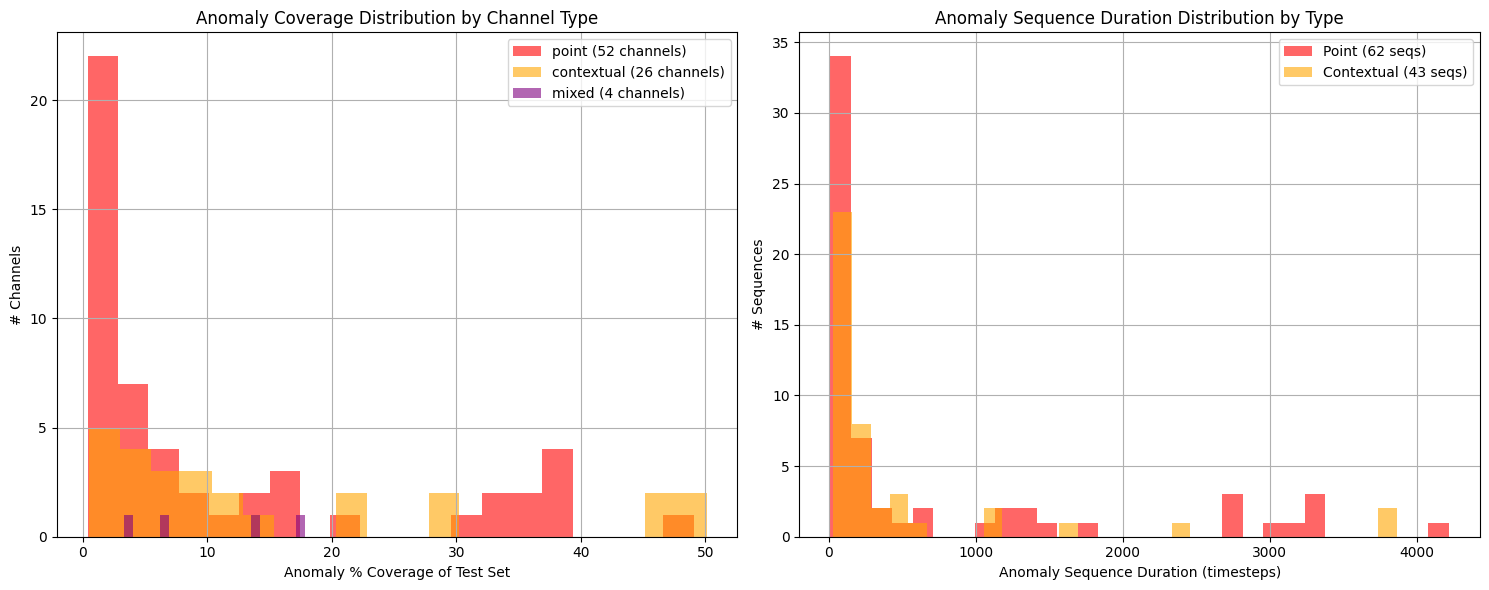

=== Coverage Stats ===
point       : n= 52  mean= 11.0%  min= 0.4%  max= 49.1%
contextual  : n= 26  mean= 15.3%  min= 0.5%  max= 50.1%
mixed       : n=  4  mean= 10.4%  min= 3.3%  max= 17.8%

=== Duration Stats ===
point       : n= 62  mean= 713.3  median= 126.0  min=  11  max=  4218
contextual  : n= 43  mean= 478.8  median= 121.0  min=  31  max=  3865


In [6]:
# Compute anomaly % coverage per channel and per-sequence durations
coverage_data  = {'point': [], 'contextual': [], 'mixed': []}
duration_data  = {'point': [], 'contextual': []}

for _, row in df_labels.iterrows():
    test_arr     = np.load(f'{TEST_DIR}/{row.chan_id}.npy')
    anom_steps   = sum(e - s + 1 for s, e in row['anomaly_sequences'])
    anom_pct     = 100 * anom_steps / len(test_arr)
    coverage_data[row['anomaly_type']].append(anom_pct)
    
    for seq, t in zip(row['anomaly_sequences'], row['class_list']):
        duration_data[t].append(seq[1] - seq[0] + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: anomaly coverage % by channel type
ax = axes[0]
colors = {'point': 'red', 'contextual': 'orange', 'mixed': 'purple'}
for atype, vals in coverage_data.items():
    if vals:
        ax.hist(vals, bins=20, alpha=0.6, label=f'{atype} ({len(vals)} channels)',
                color=colors[atype])
ax.set_xlabel('Anomaly % Coverage of Test Set')
ax.set_ylabel('# Channels')
ax.set_title('Anomaly Coverage Distribution by Channel Type')
ax.grid(True)
ax.legend()

# Right: individual sequence durations by type
ax = axes[1]
ax.hist(duration_data['point'],       bins=30, alpha=0.6, label=f'Point ({len(duration_data["point"])} seqs)',
        color='red')
ax.hist(duration_data['contextual'],  bins=30, alpha=0.6, label=f'Contextual ({len(duration_data["contextual"])} seqs)',
        color='orange')
ax.set_xlabel('Anomaly Sequence Duration (timesteps)')
ax.set_ylabel('# Sequences')
ax.set_title('Anomaly Sequence Duration Distribution by Type')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

# Print stats
print('=== Coverage Stats ===')
for atype in ['point', 'contextual', 'mixed']:
    vals = coverage_data[atype]
    if vals:
        print(f'{atype:12s}: n={len(vals):3d}  mean={np.mean(vals):5.1f}%  '
              f'min={np.min(vals):4.1f}%  max={np.max(vals):5.1f}%')

print('\n=== Duration Stats ===')
for atype in ['point', 'contextual']:
    d = duration_data[atype]
    print(f'{atype:12s}: n={len(d):3d}  mean={np.mean(d):6.1f}  '
          f'median={np.median(d):6.1f}  min={np.min(d):4d}  max={np.max(d):6d}')

In [ ]:
# Summary table: point vs contextual
rows = []
for atype in ['point', 'contextual']:
    d = duration_data[atype]
    rows.append({
        'Type':           atype,
        '# Sequences':    len(d),
        'Min Duration':   int(np.min(d)),
        'Max Duration':   int(np.max(d)),
        'Mean Duration':  f'{np.mean(d):.1f}',
        'Median Duration': f'{np.median(d):.1f}',
    })

print(pd.DataFrame(rows).to_string(index=False))

### Key Findings

**Contextual anomalies are substantially longer** than point anomalies:
- Point anomalies: typically short bursts (tens to low hundreds of timesteps)
- Contextual anomalies: sustained regime shifts (hundreds to thousands of timesteps)

This has direct implications for **threshold selection**:
- A threshold on raw values works for point anomalies (value spikes)
- A threshold on *reconstruction error* from a temporal model works for both — the model predicts "what should happen next" and errors accumulate during regime shifts even when individual values look plausible

For contextual anomalies, the anomaly window duration also means we need **sequence-level evaluation** (e.g., did we detect *any* point in the window?), not just pointwise precision/recall.

---
## Section 5 — Sample Visualizations

Six representative MSL channels illustrating the range of anomaly patterns. Feature 0 (telemetry signal) is plotted over the full test window:
- **Red shading**: point anomaly window
- **Orange shading**: contextual anomaly window

In [8]:
def plot_channel(chan_id, df_labels, ax=None, show_train=False, title_prefix=''):
    """Plot feature 0 of a channel's test data with anomaly windows shaded."""
    row = df_labels[df_labels['chan_id'] == chan_id].iloc[0]
    test_arr = np.load(f'{TEST_DIR}/{chan_id}.npy')
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 6))
        standalone = True
    else:
        standalone = False
    
    ax.plot(test_arr[:, 0], color='steelblue', linewidth=0.8, label='Feature 0 (telemetry)')
    
    anom_steps = sum(e - s + 1 for s, e in row['anomaly_sequences'])
    anom_pct   = 100 * anom_steps / len(test_arr)
    
    legend_labels = set()
    color_map = {'point': 'red', 'contextual': 'orange'}
    
    for (start, end), atype in zip(row['anomaly_sequences'], row['class_list']):
        color  = color_map.get(atype, 'purple')
        label  = f'{atype} anomaly' if atype not in legend_labels else ''
        legend_labels.add(atype)
        ax.axvspan(start, end, color=color, alpha=0.3, label=label)
    
    seq_info = ', '.join(
        f'[{s},{e}]({t})' for (s, e), t in zip(row['anomaly_sequences'], row['class_list'])
    )
    ax.set_title(
        f'{title_prefix}{chan_id} — {len(test_arr)} test steps, '
        f'{anom_pct:.1f}% anomalous | {seq_info}',
        fontsize=10
    )
    ax.set_xlabel('Test Timestep')
    ax.set_ylabel('Feature 0 (normalized)')
    ax.grid(True)
    ax.legend()
    
    if standalone:
        plt.tight_layout()
        plt.show()

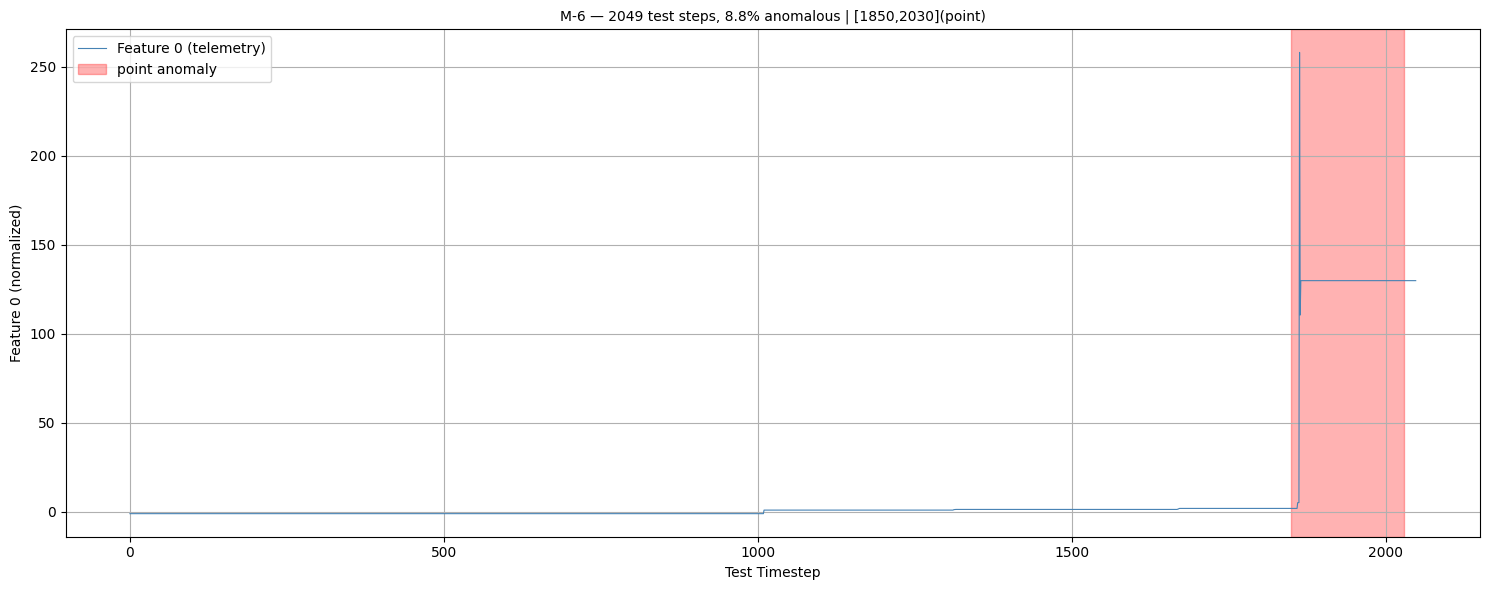

In [9]:
# M-6: dramatic point anomaly — flat at -1.0 then spike to 258
plot_channel('M-6', msl)

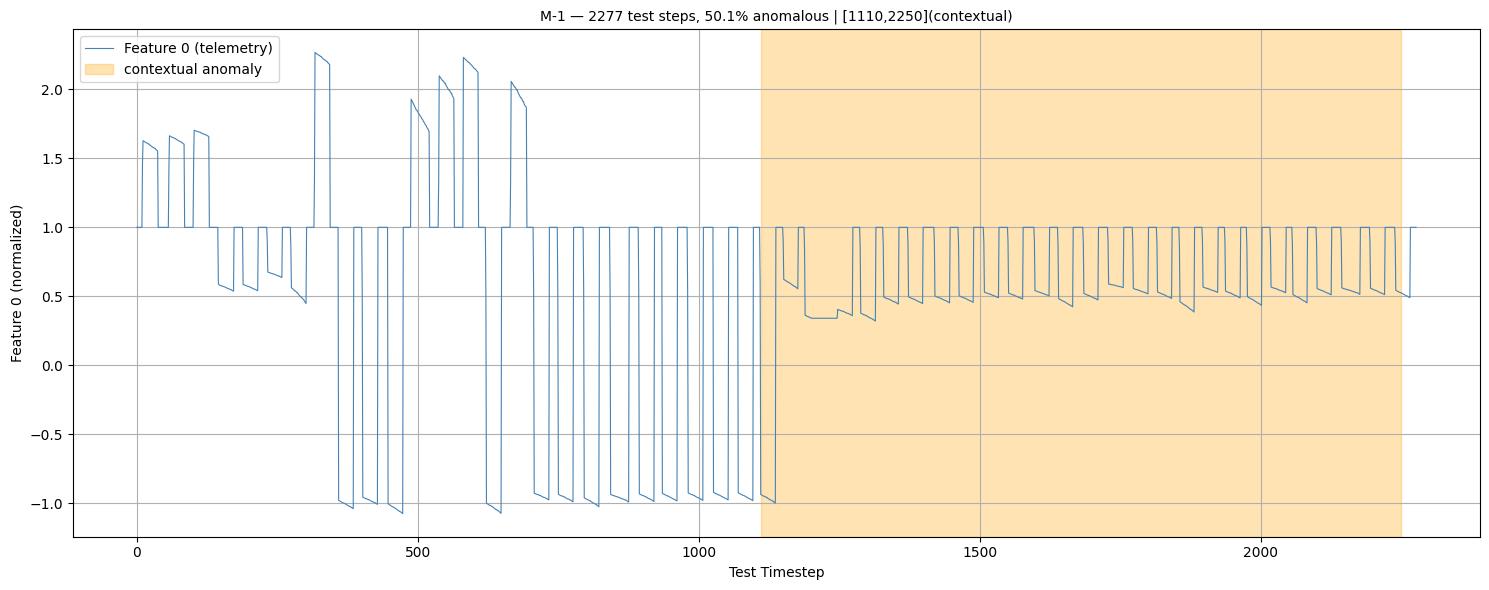

In [10]:
# M-1: contextual anomaly — 50% of test window is anomalous, regime shift pattern
plot_channel('M-1', msl)

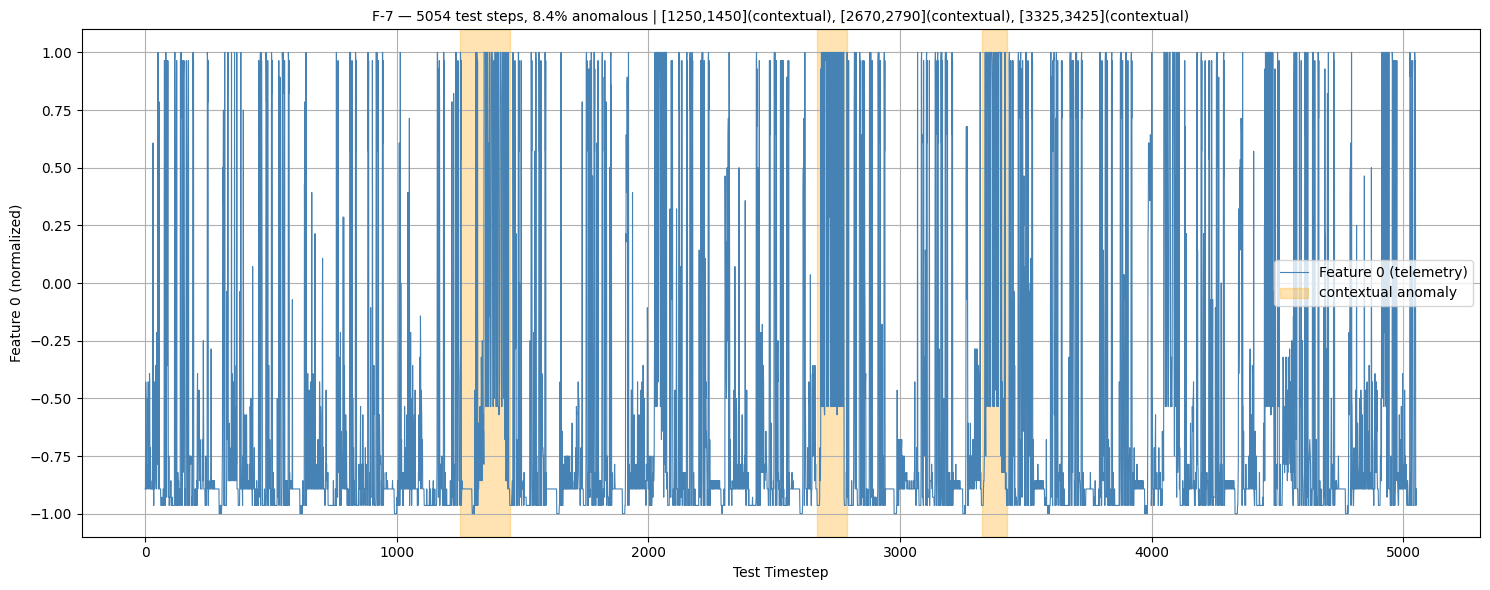

In [11]:
# F-7: 3 contextual windows in a 5054-step series — recurring behavioral shifts
plot_channel('F-7', msl)

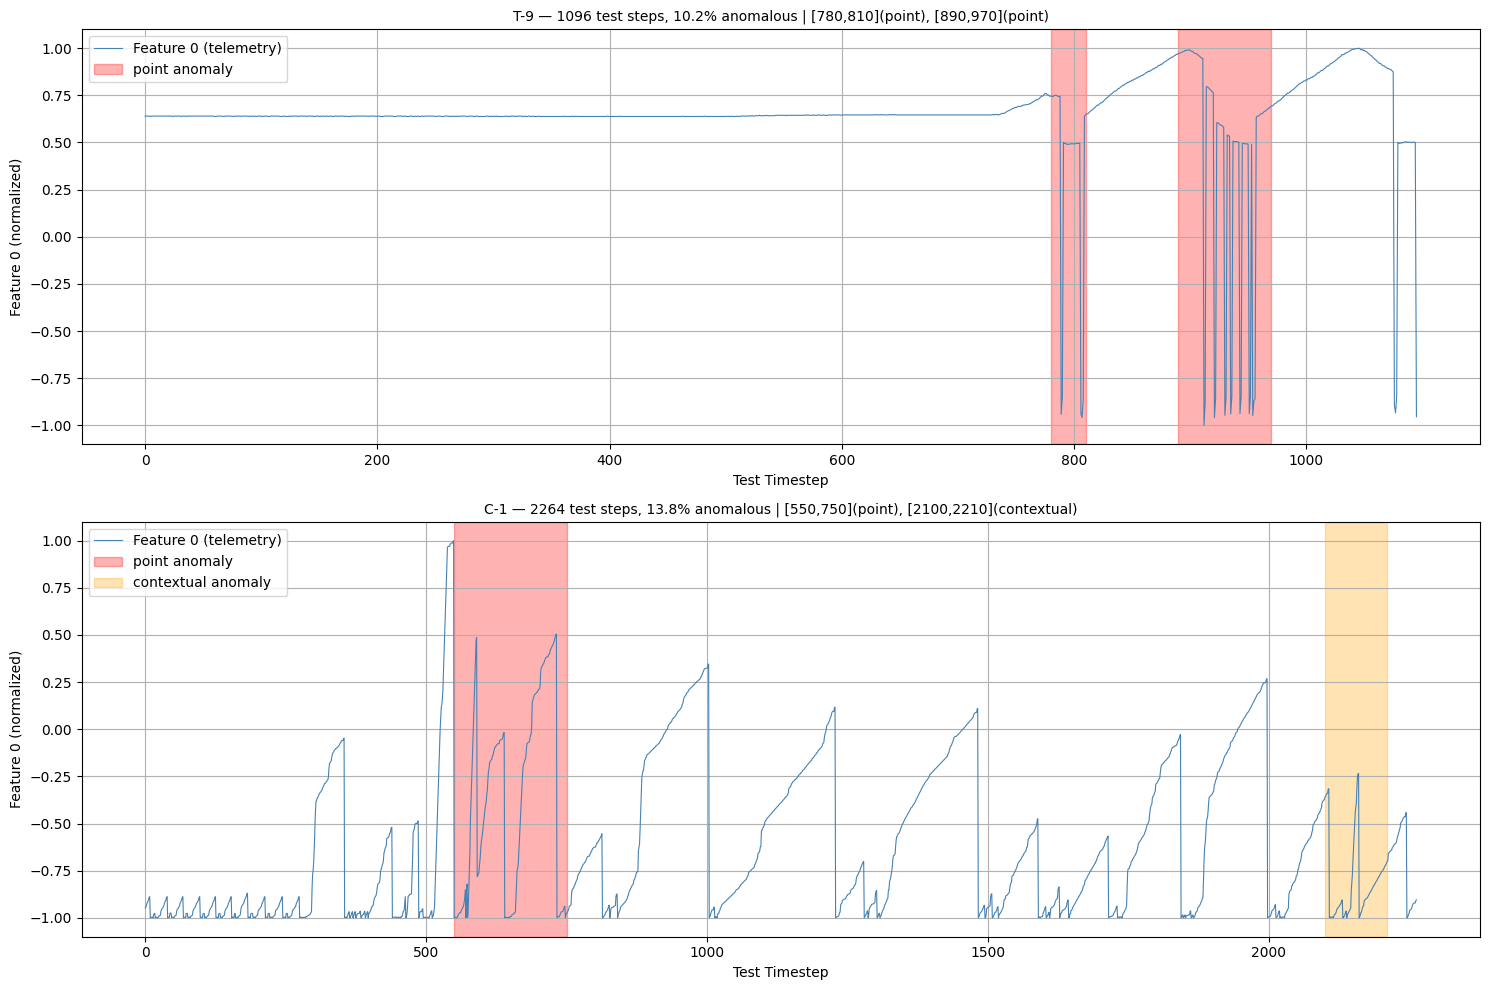

In [12]:
# T-9 + C-1 side by side
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# T-9: clustered point anomalies — two windows close together
plot_channel('T-9', msl, ax=axes[0])

# C-1: mixed type — one point + one contextual in same channel
plot_channel('C-1', msl, ax=axes[1])

plt.tight_layout()
plt.show()

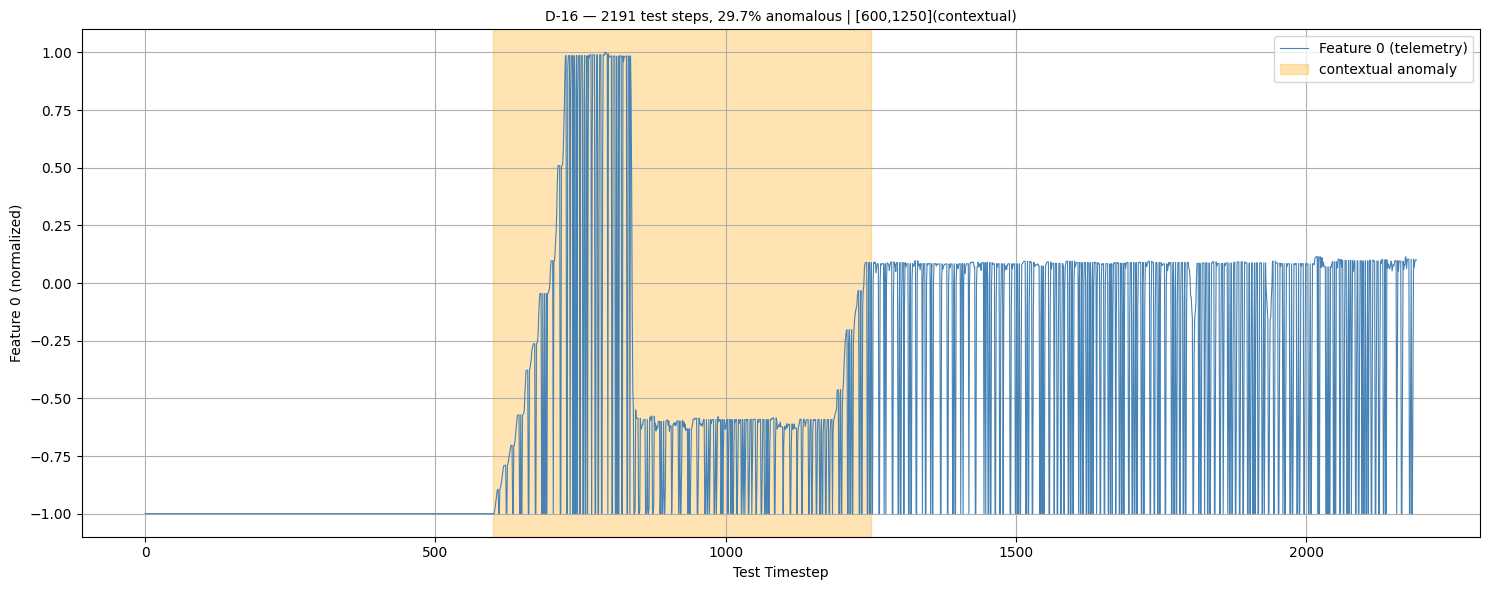

In [13]:
# D-16: single long contextual anomaly — slow regime shift covering ~30% of test
plot_channel('D-16', msl)

### Visualization Takeaways

| Channel | Type | Visual Pattern | What a Detector Needs |
|---------|------|---------------|----------------------|
| M-6 | Point | Flat signal, single spike to 258 | Any threshold on feature 0 |
| M-1 | Contextual | Oscillation pattern changes for 1141 steps | Temporal model to detect regime change |
| F-7 | Contextual | Three distinct behavioral shifts | Temporal model, robust to inter-anomaly recovery |
| T-9 | Point | Two windows close together | Threshold, but needs to handle burst patterns |
| C-1 | Mixed | One short point + one sustained contextual | Both threshold AND temporal sensitivity |
| D-16 | Contextual | Gradual drift over 30% of test | Long-context temporal model |

**Why features 1–54 matter**: Even for channels where feature 0 looks anomalous to a human eye, features 1–54 provide causal context — *why* the value changed. A model that incorporates telecommand context can distinguish "sensor reading changed because a command was issued" (normal) from "sensor reading changed with no corresponding command" (anomalous). This is the architectural opportunity for multivariate detectors.

---
## Section 6 — Train vs Test Analysis

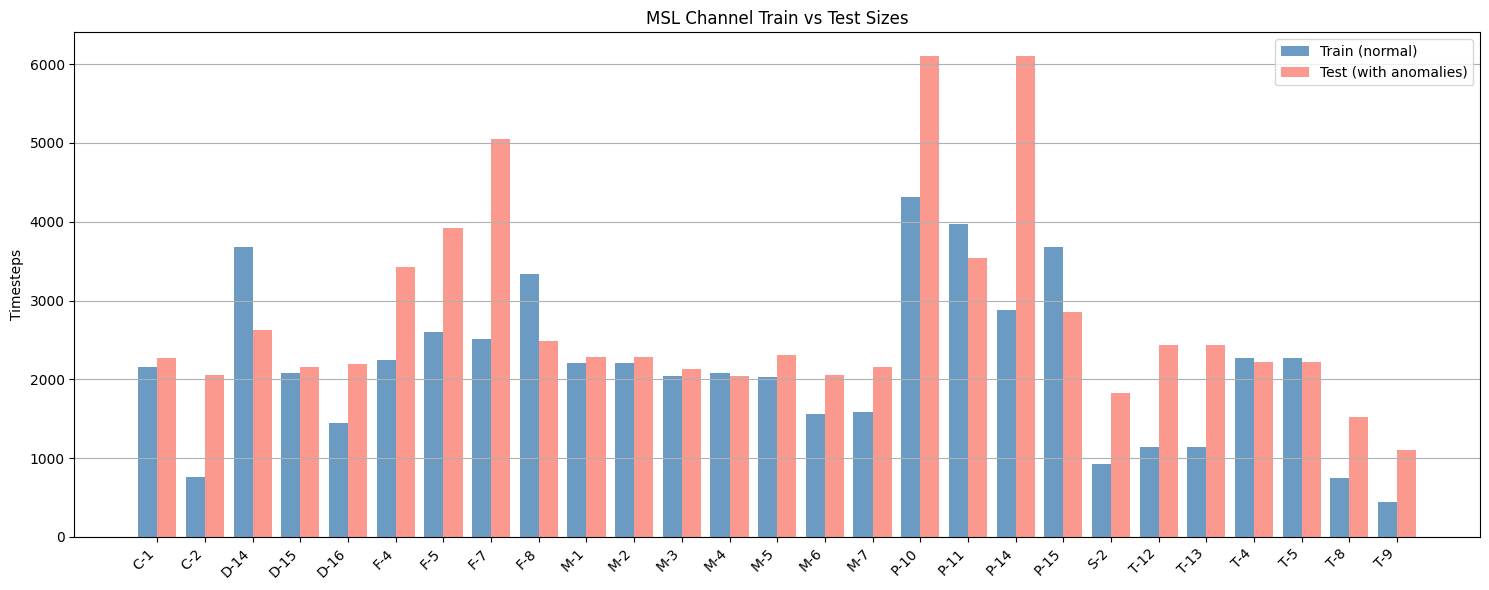

Total MSL train timesteps: 58,317
Total MSL test  timesteps: 73,729
Ratio (test/train):         1.26x


In [14]:
# Train vs Test sizes bar chart — all 27 MSL channels
channels   = sorted(msl['chan_id'].tolist())
train_sizes = [len(np.load(f'{TRAIN_DIR}/{c}.npy')) for c in channels]
test_sizes  = [len(np.load(f'{TEST_DIR}/{c}.npy'))  for c in channels]

x = np.arange(len(channels))
width = 0.4

fig, ax = plt.subplots(figsize=(15, 6))
bars1 = ax.bar(x - width/2, train_sizes, width, label='Train (normal)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_sizes,  width, label='Test (with anomalies)', color='salmon', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=45, ha='right')
ax.set_ylabel('Timesteps')
ax.set_title('MSL Channel Train vs Test Sizes')
ax.grid(True, axis='y')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Total MSL train timesteps: {sum(train_sizes):,}')
print(f'Total MSL test  timesteps: {sum(test_sizes):,}')
print(f'Ratio (test/train):         {sum(test_sizes)/sum(train_sizes):.2f}x')

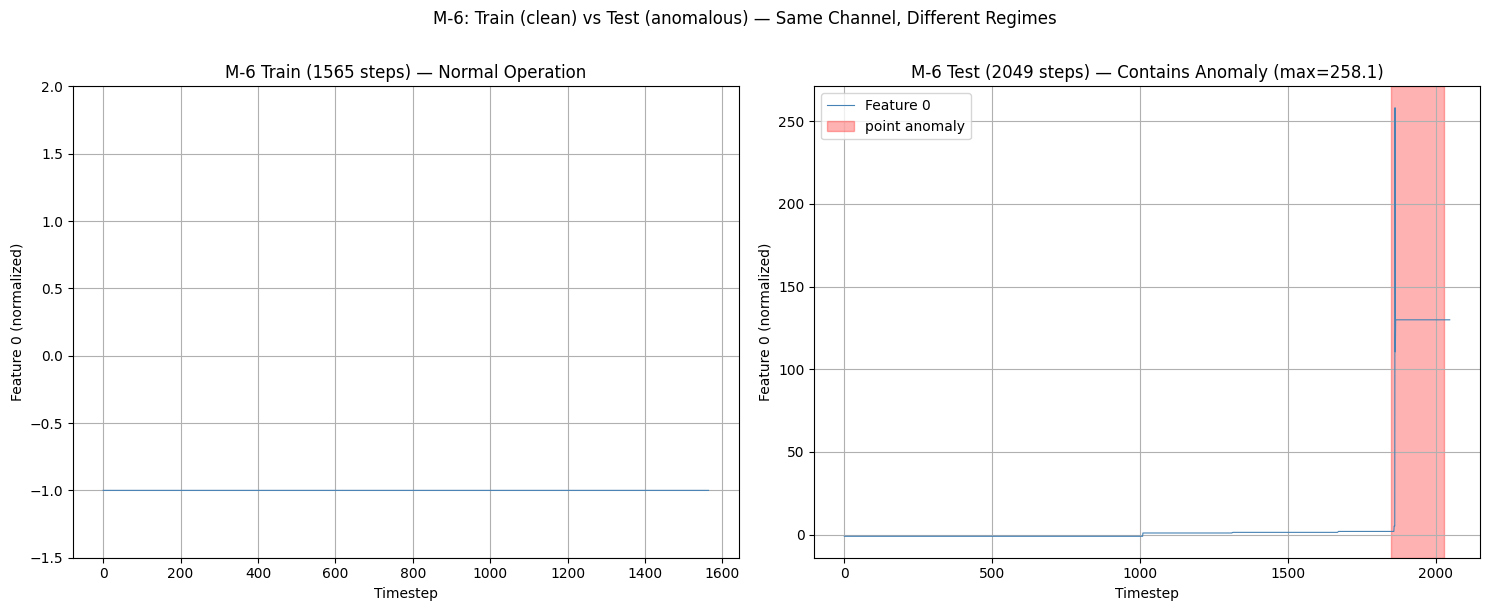

In [15]:
# M-6 train vs test comparison — demonstrates train=clean, test=anomalous paradigm
m6_train = np.load(f'{TRAIN_DIR}/M-6.npy')
m6_test  = np.load(f'{TEST_DIR}/M-6.npy')
m6_row   = msl[msl['chan_id'] == 'M-6'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: M-6 train
axes[0].plot(m6_train[:, 0], color='steelblue', linewidth=0.8)
axes[0].set_title(f'M-6 Train ({len(m6_train)} steps) — Normal Operation')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Feature 0 (normalized)')
axes[0].set_ylim(-1.5, 2)
axes[0].grid(True)

# Right: M-6 test with anomaly shaded
axes[1].plot(m6_test[:, 0], color='steelblue', linewidth=0.8, label='Feature 0')
for (start, end), atype in zip(m6_row['anomaly_sequences'], m6_row['class_list']):
    color = 'red' if atype == 'point' else 'orange'
    axes[1].axvspan(start, end, color=color, alpha=0.3, label=f'{atype} anomaly')
axes[1].set_title(f'M-6 Test ({len(m6_test)} steps) — Contains Anomaly (max={m6_test[:,0].max():.1f})')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Feature 0 (normalized)')
axes[1].grid(True)
axes[1].legend()

plt.suptitle('M-6: Train (clean) vs Test (anomalous) — Same Channel, Different Regimes', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# SMAP vs MSL structural comparison: P-1 (SMAP) vs M-1 (MSL)
p1_train = np.load(f'{TRAIN_DIR}/P-1.npy')
p1_test  = np.load(f'{TEST_DIR}/P-1.npy')

comparison = pd.DataFrame([
    {
        'Channel':          'P-1 (SMAP)',
        'Train Shape':      str(p1_train.shape),
        'Test Shape':       str(p1_test.shape),
        'Train Value Range': f'[{p1_train.min():.3f}, {p1_train.max():.3f}]',
        'Test Value Range':  f'[{p1_test.min():.3f},  {p1_test.max():.3f}]',
        'Features':         p1_train.shape[1],
    },
    {
        'Channel':          'M-1 (MSL)',
        'Train Shape':      str(m1_train.shape),
        'Test Shape':       str(m1_test.shape),
        'Train Value Range': f'[{m1_train.min():.3f}, {m1_train.max():.3f}]',
        'Test Value Range':  f'[{m1_test.min():.3f},  {m1_test.max():.3f}]',
        'Features':         m1_train.shape[1],
    }
])

print('=== SMAP vs MSL Structural Comparison ===')
print(comparison.to_string(index=False))

=== SMAP vs MSL Structural Comparison ===
   Channel Train Shape Test Shape Train Value Range Test Value Range  Features
P-1 (SMAP)  (2872, 25) (8505, 25)   [-1.000, 1.000] [-1.000,  1.000]        25
 M-1 (MSL)  (2209, 55) (2277, 55)   [-0.916, 2.492] [-1.076,  2.269]        55


---
## Summary & Roadmap

### Dataset Structure
- **82 channels** (55 SMAP × 25 features, 27 MSL × 55 features)
- **Train**: nominal operation only — used to learn expected behavior
- **Test**: contains labeled anomaly windows — anomaly indices reference test array positions
- **Feature 0**: primary telemetry signal; **features 1–54 (MSL)**: binary telecommand context

### Anomaly Landscape
- **105 total sequences**: 62 point + 43 contextual
- Contextual anomalies are **longer** (sustained regime shifts) and **cannot** be detected by value-level thresholds
- Coverage ranges from <1% (S-2) to ~50% (M-1, M-2)
- Some channels have multiple anomaly windows of different types (C-1: mixed)

### 5 Data-Loading Gotchas

1. **`class` column is not valid Python** — `[contextual, point]` has unquoted strings. Use `str.split()`, not `ast.literal_eval()`.
2. **`anomaly_sequences` is valid JSON** — use `ast.literal_eval()` to get list of `[start, end]` pairs.
3. **Anomaly indices reference the TEST array** — not a combined train+test index.
4. **Double `data/` in path** — Kaggle download preserved the inner folder: `data/NASA/data/data/train/`.
5. **Test values can far exceed [-1, 1]** — normalization uses training statistics; M-6 test reaches 258. Do not clip test data.

### What to Build Next

The EDA establishes the key challenge: **43% of anomalies are contextual** and require temporal models. The recommended path:

1. **LSTM-based anomaly detector** — train on M-1 or F-7 normal sequences, predict next step, use reconstruction error as anomaly score
2. **Sequence-level evaluation protocol** — standard pointwise F1 is misleading; use window-based detection (did the model fire at any point in the anomaly window?)
3. **Multivariate baseline** — include features 1–54 to see if telecommand context improves detection of contextual anomalies